In [1]:
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv("Iris.csv")

In [3]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

<Axes: >

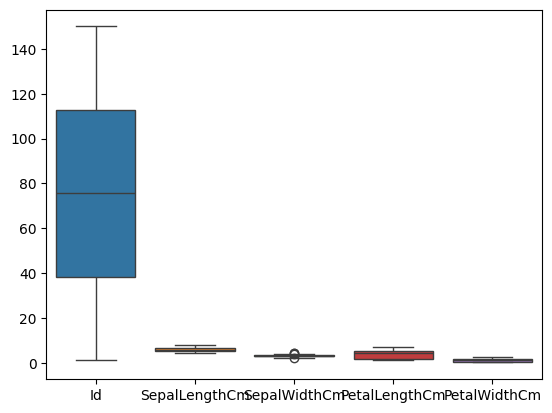

In [5]:
sns.boxplot(data=data)

In [6]:
# IQR for SepalWidthCm
q1 = data['SepalWidthCm'].quantile(0.25)
q3 = data['SepalWidthCm'].quantile(0.75)
iqr = q3-q1

lower = q1-1.5*iqr
upper = q3+1.5*iqr

data = data[(data['SepalWidthCm'] >= lower) & (data['SepalWidthCm'] <= upper)]

<Axes: >

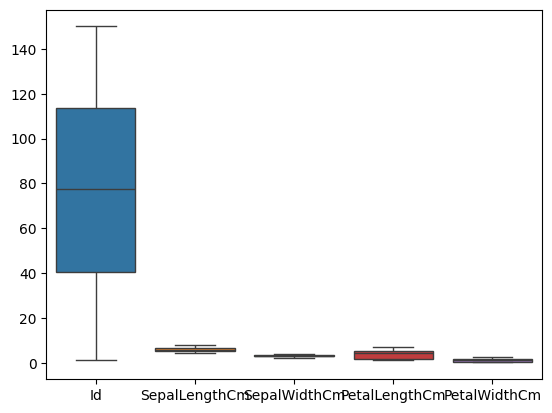

In [7]:
sns.boxplot(data=data)

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data['Species'] = le.fit_transform(data['Species'])

In [9]:
data['Species'].value_counts()

Species
2    50
1    49
0    47
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

x = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = data[['Species']]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2)

gauss = GaussianNB()
gauss.fit(xtrain, ytrain)

C:\Users\Shreyash Nathe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
gauss.score(xtest, ytest)

1.0